이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- numpy
- matplotlib

- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 10-1 병렬 처리를 위한 새로운 패러다임, 트랜스포머

본 노트북은 본문 10-1절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 학습 가능한 위치 인코딩을 구현한 `PositionalEncoding` 클래스
- `nn.Transformer`로 인코더와 디코더를 한 번에 만드는 `DateConverterTransformer`
- 어텐션 헤드 수와 데이터에 따른 성능 비교([표 10-4])
- 인코더를 한 번만 호출하고 디코더를 반복 호출하는 예측 함수
- 멀티헤드 어텐션의 헤드별 가중치 시각화

9장의 날짜 변환기 모델을 트랜스포머 구조로 다시 만든다. 데이터는 9-3절과 같은 노이즈가 섞인 입력을 사용한다.

## 데이터와 데이터로더

- 데이터 생성, 어휘 사전, 데이터셋, 배치 병합 함수는 9장과 같다.
    - 특수 토큰은 `<sos>`, `<eos>`, `<pad>`를 사용한다.
    - 자세한 설명은 9-2절과 9-3절 노트북을 참고하자.

In [2]:
# 참고 - 데이터 생성(9-3절과 동일한 데이터 사용)
from datetime import datetime, timedelta
import random
import string

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# datetime 리스트를 입력 리스트와 정답 리스트로 변환하는 함수
# 입력은 src_formats에 정의된 형식으로, 정답은 'YYYY-M-D' 형식으로 변환
def generate_datepairs(date_list, src_formats=src_formats):
    if len(src_formats) == 0:
        raise ValueError('입력 문자열 템플릿이 비어 있습니다.')
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(date.strftime(src_format))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates

# 날짜 문자열 앞뒤에 무작위 길이의 무작위 노이즈를 덧붙인 문자열 생성
def add_random_noise(text, max_length=40):
    noise_chars = (
        string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    )
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix_length = random.randint(0, remaining)
        suffix = ''.join(random.choices(noise_chars, k=suffix_length))
    return prefix + text + suffix

# 노이즈가 추가된 날짜 문자열 쌍 생성 함수
def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(src_format)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates

# 4,000개의 (노이즈가 섞인 입력, 정답) 날짜 쌍 생성
date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_noisy_datepairs(date_list)
print('노이즈 데이터셋 예시:')
for i in range(4):
    print(f'  {src_dates[i]!r} -> {tgt_dates[i]!r}')

노이즈 데이터셋 예시:
  'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'
  ']qDOx[U4120E=2_!A2hlkBq9T24 Dec 19191ZL' -> '1919-12-24'
  '495?XRmBOeFam_/June 28, 19046KR@NoY(' -> '1904-6-28'
  'zyVoO%&Jan 21, 2033TYxW?W^^NtL$6w]cx' -> '2033-1-21'


In [3]:
# 참고 - 어휘 사전, 데이터셋, 데이터로더(9-3절과 동일)
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX}

from torch.utils.data import Dataset

# 특수 토큰 조합에 <pad> 추가
SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX}

# 어휘 사전 클래스(Vocab)는 9-1절과 동일
class Vocab:
    def __init__(self, sequence_list, special_tokens):
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        self.vocab = dict(special_tokens)
        idx_start = len(special_tokens)
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        self.itos = {idx: token for token, idx in self.vocab.items()}

    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    def __len__(self):
        return len(self.vocab)

# 데이터셋 클래스: 텐서 변환 제거
class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = []
        for src_date, tgt_date in zip(src_dates, tgt_dates):
            src_ids = src_vocab.encode(src_date)
            tgt_ids = tgt_vocab.encode(tgt_date)
            tgt_ids = [SOS_IDX] + tgt_ids + [EOS_IDX]
            self.samples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src_ids, tgt_ids = self.samples[idx]
        # 텐서 변환 없이 정수 리스트를 반환(데이터로더가 텐서로 변환해 모델에 전달)
        return src_ids, tgt_ids

# 배치 병합 함수
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_tensors = [torch.tensor(s, dtype=torch.long) for s in src_batch]
    tgt_tensors = [torch.tensor(t, dtype=torch.long) for t in tgt_batch]
    src_padded = pad_sequence(src_tensors, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_tensors, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded

# 어휘 사전 생성
src_vocab = Vocab(src_dates, special_tokens)
tgt_vocab = Vocab(tgt_dates, special_tokens)

# 데이터셋(훈련/검증) 생성
train_set = DateDataset(src_dates[:3000], tgt_dates[:3000], src_vocab, tgt_vocab)
valid_set = DateDataset(src_dates[3000:], tgt_dates[3000:], src_vocab, tgt_vocab)

# 배치 크기 32인 데이터로더 생성
BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'입력 어휘 사전 크기: {len(src_vocab)}')
print(f'출력 어휘 사전 크기: {len(tgt_vocab)}')
print(f'훈련/검증 데이터셋: {len(train_set)} / {len(valid_set)}')

입력 어휘 사전 크기: 93
출력 어휘 사전 크기: 14
훈련/검증 데이터셋: 3000 / 1000


## 학습 가능한 위치 인코딩

- 트랜스포머는 모든 토큰을 한 번에 처리하므로 순서 정보를 따로 넣어 줘야 한다.
- 위치 인덱스(0, 1, 2, ...)를 임베딩 계층으로 벡터화해 토큰 임베딩에 더하는 방식을 학습 가능한 위치 인코딩이라고 한다.
    - 본문 [표 10-3]은 사인/코사인 기반 방식과 학습 가능한 방식을 비교한다.

In [4]:
######################################################################################
# 코드 10-1 - 학습 가능한 위치 인코딩을 구현한 PositionalEncoding 클래스
######################################################################################

import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, max_length, d_model):
        super().__init__()
        # 0번 위치부터 max_length-1번 위치까지 각각의 위치 인코딩 벡터를 학습
        self.position_embedding = nn.Embedding(max_length, d_model)
        # tanh 활성화 함수: 임베딩 + 위치 인코딩 합산값의 범위를 -1~1로 제한
        #   표준 트랜스포머 아키텍쳐에는 사용하지 않지만, 짧은 순차 데이터에서 학습을 안정시키기 위해 사용
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        # 순차 데이터 길이에 따른 위치 인덱스 텐서 생성(0, 1, 2, ... 순서)
        #   : device=token_embedded.device로 토큰 임베딩과 위치 인덱스 위치를 맞춤
        positions = torch.arange(seq_length, device=token_embedded.device)
        # 위치 인코딩: (seq_length, d_model), d_model은 위치를 포함한 토큰 임베딩 차원
        pos_embedded = self.position_embedding(positions)
        # 위치 인코딩과 토큰 임베딩을 더해서 결합(위치 인코딩은 브로드캐스팅 후 더해짐)
        combined_embedded = token_embedded + pos_embedded
        # 활성화 함수 적용 후 반환
        return self.activation(combined_embedded)

## DateConverterTransformer 모델

- `nn.Transformer` 하나로 인코더와 디코더를 함께 만든다.
    - `d_model`은 트랜스포머 내부를 흐르는 벡터의 길이로, 토큰 임베딩의 크기와 같아야 한다.
    - `nhead`는 멀티헤드 어텐션의 헤드 수, `dim_feedforward`는 블록 안 순방향 신경망의 폭이다.
- 디코더의 셀프 어텐션에는 미래 토큰을 가리는 인과 마스크가 필요하다([그림 10-3]).
    - `nn.Transformer.generate_square_subsequent_mask()`로 만들 수 있다.
- 패딩 마스크는 트랜스포머 계열 클래스의 규약에 따라 `<pad>` 위치가 `True`인 마스크를 사용한다.

In [5]:
######################################################################################
# 코드 10-2, 10-3 - DateConverterTransformer 클래스의 생성자와 forward() 메서드
######################################################################################

class DateConverterTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, 
                 ff_dim, num_layers, max_length, dropout):
        super().__init__()
        # 입력과 정답 토큰 임베딩 계층: 입력과 정답 임베딩은 별도로 학습
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_IDX)
        # 위치 인코딩 계층: 입력과 정답의 위치 인코딩은 공유
        self.pos_encoding = PositionalEncoding(max_length, d_model)
        # 토큰 임베딩 + 위치 인코딩에 적용하는 드롭아웃 계층
        self.dropout = nn.Dropout(dropout)
        # 트랜스포머 블록 계층(인코더 + 디코더)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=num_heads,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True
        )
        self.fc = nn.Linear(d_model, tgt_vocab_size)
    
    def forward(self, src, tgt):
        tgt_input = tgt[:, :-1]                     # 정답에서 <eos> 제거해 디코더에 입력
        # 입력 패딩 마스크: nn.Transformer 계열은 <pad> 위치가 True인 마스크를 사용
        src_pad_mask = (src == PAD_IDX)             # (B, src_length)
        # 정답 패딩 마스크
        tgt_pad_mask = (tgt_input == PAD_IDX)       # (B, tgt_length - 1)
        # 인과 마스크: 미래 토큰을 참조하지 못하도록 오른쪽 위 삼각 위치를 -inf로 채움
        tgt_causal_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_input.size(1), device=src.device
        )                                           # (tgt_length - 1, tgt_length - 1)

        # 토큰 임베딩 (입력/정답 별도 계층 사용)
        src_token_embedded = self.src_embedding(src)
        tgt_token_embedded = self.tgt_embedding(tgt_input)
        # 토큰 임베딩과 위치 인코딩 결합(입력/정답 같은 계층 사용)
        src_embedded = self.pos_encoding(src_token_embedded)
        tgt_embedded = self.pos_encoding(tgt_token_embedded)
        # 특정 입력-정답 조합에 과적합되는 것을 피하기 위해 드롭아웃 적용
        src_embedded = self.dropout(src_embedded)
        tgt_embedded = self.dropout(tgt_embedded)

        outputs = self.transformer(
            src_embedded, tgt_embedded,
            tgt_mask=tgt_causal_mask,               # 인과 마스크(미래 토큰 차단)
            src_key_padding_mask=src_pad_mask,      # 인코더 셀프 어텐션의 입력 패딩 마스크
            tgt_key_padding_mask=tgt_pad_mask,      # 디코더 셀프 어텐션의 정답 패딩 마스크
            memory_key_padding_mask=src_pad_mask    # 크로스 어텐션의 메모리 패딩 마스크
        )                                           # (B, tgt_length - 1, d_model)
        return self.fc(outputs)                     # (B, tgt_length - 1, tgt_vocab_size)

## 모델의 학습([표 10-4])

- 학습 함수는 9장과 거의 같다. LSTM 패킹과 언패킹이 필요 없으므로 길이 정보 텐서를 만들지 않고, 대신 패딩 마스크와 인과 마스크를 사용한다.
- 본문은 검증 함수와 학습 루프를 싣지 않았다.

In [6]:
# 참고 - 학습 함수
#   9장의 학습 함수와 거의 비슷하지만, LSTM을 사용하지 않으므로 패킹, 언패킹이 없고, 
#   길이 정보 텐서와 관련된 부분도 제외했다.

import contextlib, io, copy

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt)                # (B, T-1, vocab_size)
        labels = tgt[:, 1:]                     # <sos> 제거
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size


@torch.no_grad()
def validation(model, loader, criterion, device):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    loss_sum, sample_size, correct_size = 0.0, 0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt)
        labels = tgt[:, 1:]
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
        preds = logits.argmax(dim=-1)
        mask = labels != PAD_IDX
        # <pad> 위치를 제외하고 샘플 별 정답/오답을 판정해 취합
        sample_correct = ((preds == labels) | ~mask).all(dim=1)
        correct_size += sample_correct.sum().item()
    return loss_sum / sample_size, correct_size / sample_size * 100.0


def train_with_early_stop(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device=None, verbose=True):
    if device is None:
        device = torch.device('cpu')
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)
    best_valid_loss = float('inf')
    best_state, counter = None, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = validation(model, valid_loader, criterion, device)
        if verbose:                             # 로그 출력 활성 모드
            log.row(epoch, train_loss, valid_loss, valid_acc)
        else:                                   # 로그 출력 비활성 모드            
            with contextlib.redirect_stdout(io.StringIO()):
                log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    if verbose:
        log.summary(stopped='조기 종료' if stopped else None)
    return log

In [7]:
######################################################################################
# 코드 10-4 - DateConverterTransformer 모델 객체 생성과 학습
######################################################################################

# [표 10-4]의 모델 라에 해당
import torch.optim as optim

# 모델 구조 하이퍼파라미터 설정
D_MODEL = 64
NUM_HEADS = 4       # 멀티헤드 어텐션의 헤드 수: D_MODEL의 약수여야 함
FF_DIM = 128        # 트랜스포머 내부 선형 계층의 크기
NUM_LAYERS = 1      # 사용할 인코더/디코더 기본 블록의 수
MAX_LENGTH = 64     # 처리할 수 있는 최대 순차 데이터 길이
DROPOUT = 0.1       # 트랜스포머와 별도 드롭아웃 계층에 적용할 비율

# 학습 하이퍼파라미터 설정  
LR = 1e-3           # 학습률
EPOCHS = 200        # 전체 학습 에포크
PATIENCE = 10       # 조기 종료를 위한 참을성 한계
'''
트랜스포머 모델은 학습 에포크가 더 많이 필요하므로 참을성 한계를 넉넉히 잡는다.
공정한 비교를 위해 본문의 표로 제시한 9-3절의 어텐션 모델도 참을성 한계를 10으로 
늘려서 학습한 결과를 사용한다.
'''

# 재현을 위한 시드값 초기화
common.set_seed(SEED)

# 모델 객체 생성
model = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    d_model=D_MODEL, num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT
).to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 모델 학습
log = train_with_early_stop(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True
)

/home/crapas/.local/lib/python3.12/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


/home/crapas/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4305       1.0756        0.00%     0:02


  2/200       1.0727       0.9889        0.00%     0:04


  3/200       1.0032       0.9282        0.10%     0:05


...

196/200       0.0397       0.0166       95.40%     4:30


197/200       0.0371       0.0195       95.00%     4:31


198/200       0.0348       0.0197       94.90%     4:32


199/200       0.0340       0.0172       95.40%     4:34


200/200       0.0387       0.0152       95.70%     4:35
-------------------------------------------------------
최적 200 에포크 · 검증 손실 0.0152 · 전체 학습 시간 4:35


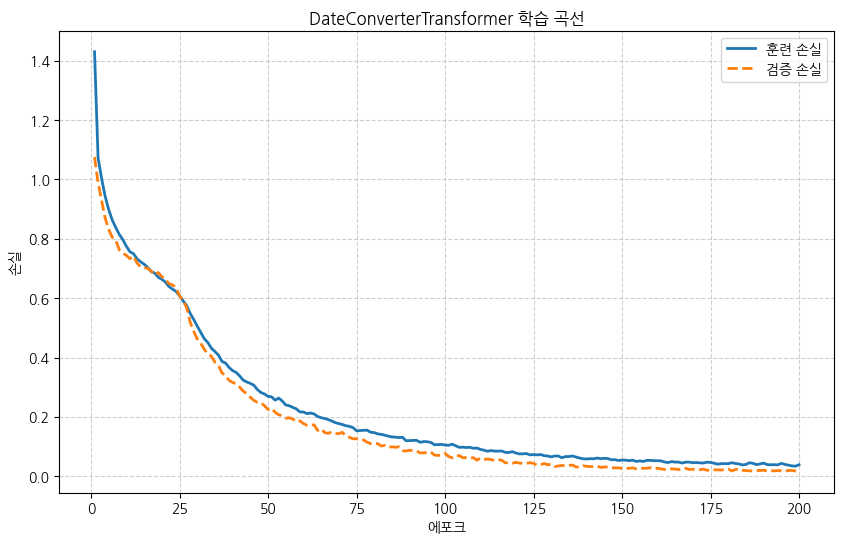

In [8]:
# 참고 - 학습 곡선 시각화
log.plot(title='DateConverterTransformer 학습 곡선')

- 비교를 위해 본문 [표 10-4]의 모델 다(헤드 1, 노이즈 데이터)와 모델 가(헤드 1, 깨끗한 데이터)도 학습한다.
    - 본문 예제([코드 10-4])는 헤드 4, 노이즈 데이터를 사용하는 모델 라에 해당한다.

In [9]:
# 참고 - 멀티헤드 어텐션의 헤드 수 1, 노이즈 데이터 사용 학습([표 10-4]의 모델 다)

# 재현을 위한 시드값 초기화
common.set_seed(SEED)

# 모델 객체 생성
model_single_head = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    d_model=D_MODEL, num_heads=1, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT
).to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model_single_head.parameters(), lr=LR)

# 모델 학습
log = train_with_early_stop(
    model_single_head, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True
)

/home/crapas/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4308       1.0810        0.00%     0:01


  2/200       1.0881       0.9992        0.10%     0:03


  3/200       1.0247       0.9545        0.00%     0:04


  4/200       0.9780       0.9052        0.10%     0:05


...

167/200       0.1729       0.0542       84.40%     3:16


168/200       0.1741       0.0548       83.90%     3:18


169/200       0.1771       0.0527       85.40%     3:19


170/200       0.1728       0.0536       83.90%     3:20


171/200       0.1721       0.0596       83.00%     3:21
-------------------------------------------------------
최적 161 에포크 · 검증 손실 0.0456 · 전체 학습 시간 3:21 · (조기 종료)


In [10]:
# 참고 - 멀티헤드 어텐션의 헤드 수 1, 클린 데이터 사용 학습([표 10-4]의 모델 가)

# 클린 데이터 생성 (9-2절과 동일)
date_list_clean = choice_random_dates(4000)
src_dates_clean, tgt_dates_clean = generate_datepairs(date_list_clean)

src_vocab_clean = Vocab(src_dates_clean, special_tokens)
tgt_vocab_clean = Vocab(tgt_dates_clean, special_tokens)
train_set_clean = DateDataset(src_dates_clean[:3000], tgt_dates_clean[:3000], src_vocab_clean, tgt_vocab_clean)
valid_set_clean = DateDataset(src_dates_clean[3000:], tgt_dates_clean[3000:], src_vocab_clean, tgt_vocab_clean)
train_loader_clean = DataLoader(train_set_clean, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader_clean = DataLoader(valid_set_clean, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# 재현을 위한 시드값 초기화
common.set_seed(SEED)

# 모델 객체 생성
model_clean_data = DateConverterTransformer(
    src_vocab_size=len(src_vocab_clean), tgt_vocab_size=len(tgt_vocab_clean),
    d_model=D_MODEL, num_heads=1, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT
).to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model_clean_data.parameters(), lr=LR)

# 클린 데이터로 모델 학습
log = train_with_early_stop(
    model_clean_data, train_loader_clean, valid_loader_clean, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True
)

'''
참고로, 헤드수 4인 모델의 경우 더 빨리 100% 정확도에 도달한다.
'''

 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.3918       0.7718        2.30%     0:01


  2/200       0.7046       0.3231       35.60%     0:02


  3/200       0.4497       0.1647       58.30%     0:03


  4/200       0.3403       0.0926       75.00%     0:05


  5/200       0.2769       0.0619       82.30%     0:06


...

 61/200       0.0733       0.0005       99.80%     1:12


 62/200       0.0691       0.0003      100.00%     1:13


 63/200       0.0678       0.0005       99.80%     1:14


 64/200       0.0698       0.0004       99.90%     1:15
-------------------------------------------------------
최적 54 에포크 · 검증 손실 0.0003 · 전체 학습 시간 1:15 · (조기 종료)


'\n참고로, 헤드수 4인 모델의 경우 더 빨리 100% 정확도에 도달한다.\n'

In [11]:
# 참고 - 각 모델의 학습 파라미터 수 

# 학습 파라미터 수를 반환하는 함수
def get_parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models = [model, model_single_head, model_clean_data]
model_names = ['모델 라(4 헤드)', '모델 다(1 헤드)', '모델 가(1 헤드/클린 데이터)']
parameter_counts = [get_parameter_count(m) for m in models]

for name, count in zip(model_names, parameter_counts):
    print(f'{name} 모델 파라미터 수: {count:,}')

모델 라(4 헤드) 모델 파라미터 수: 95,822
모델 다(1 헤드) 모델 파라미터 수: 95,822
모델 가(1 헤드/클린 데이터) 모델 파라미터 수: 92,622


- 본문 [표 10-4]의 수치와 비교해 보자.

| | 모델 가 | 모델 나 | 모델 다 | 모델 라 |
|---|---|---|---|---|
| 모델 구조 | 트랜스포머 | 바다나우 어텐션 | 트랜스포머 | 트랜스포머 |
| 어텐션 헤드 수 | 1 | - | 1 | 4 |
| 학습 데이터 | 깨끗한 데이터 | 노이즈 추가 데이터 | 노이즈 추가 데이터 | 노이즈 추가 데이터 |
| 파라미터(개) | 92,622 | 26,990 | 95,822 | 95,822 |
| 최적 에포크 | 58 | 63 | 131 | 159 |
| 학습 시간(초) | 68 (1.0) | 216 (3.2) | 136 (1.0) | 180 (1.1) |
| 검증 정확도(%) | 99.00 | 90.10 | 82.80 | 94.10 |

- 모델 나(어텐션 Seq2Seq)는 9-3절 노트북에서 학습한다.
- 깨끗한 데이터라면 멀티헤드 없이도 정확한 모델을 만들 수 있다(모델 가).
- 노이즈 데이터에서는 단일 헤드 트랜스포머(모델 다)가 순환 신경망 기반 모델 나에도 못 미친다.
    - 순환 신경망은 입력을 순서대로 읽으며 문맥을 쌓아 가는 구조적 이점이 있다.
    - 멀티헤드 어텐션은 여러 헤드가 서로 다른 관점을 동시에 보게 해 표현력을 끌어올린다(모델 라).
- 단일 헤드와 멀티헤드는 파라미터 수가 같고 에포크당 학습 시간도 큰 차이가 없다.

## 예측 함수

- 트랜스포머 계층은 입력과 정답을 함께 받아 동작하므로, 추론에서는 모델 객체를 그대로 사용할 수 없다.
- 입력은 고정되어 있으므로 인코더를 한 번만 호출해 메모리를 만든다([코드 10-5]).
    - 파이토치는 인코더의 출력에 해당하는 입력 셀프 어텐션을 `memory`라고 부른다. 9-3절의 `encoder_output`과 같은 역할이다.
- 디코더는 내부 상태가 없으므로, 지금까지 생성한 토큰 전체를 매번 전달한다([코드 10-6]).
    - 디코더는 입력한 토큰마다 출력을 내놓으므로 마지막 위치(`[:, -1, :]`)의 로짓만 골라 다음 토큰을 생성한다.
    - `decoder_input`의 길이가 반복마다 늘어나므로 인과 마스크를 매번 새로 만든다.

In [12]:
######################################################################################
# 코드 10-5, 10-6 - 트랜스포머 모델의 예측 함수
######################################################################################

@torch.no_grad()
def predict(model, src_text, src_vocab, tgt_vocab, device, max_length=12):
    # 인코더 실행([코드 10-5])
    # src_text: 토큰 고유 번호의 텐서로 변환할 입력 순차 데이터
    src_ids = src_vocab.encode(src_text)
    src_tensor = torch.LongTensor(src_ids).unsqueeze(0).to(device)
    # 토큰 임베딩 + 위치 인코딩
    src_embedded = model.pos_encoding(model.src_embedding(src_tensor))
    # 패딩 마스크: 트랜스포머 계열 클래스는 <pad> 위치가 True인 마스크 사용
    src_pad_mask = (src_tensor == PAD_IDX)
    # 인코더는 한 번만 호출하면 됨(추론 시 인코더 출력은 변하지 않음)
    memory = model.transformer.encoder(src_embedded, src_key_padding_mask=src_pad_mask)

    # 디코더를 반복 실행해 결과 생성([코드 10-6])
    #   인과 마스크 -> 토큰 임베딩 + 위치 인코딩 -> 디코더 -> 분류기 순으로
    #   토큰 하나씩 생성하는 과정을 반복해 출력 순차 데이터 생성
    # <sos> 토큰 하나로 디코더 입력 시작(배치 크기 1)
    decoder_input = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
    result = []
    # 인과 마스크 생성, 임베딩 + 위치 인코딩, 디코더 호출, 분류기 순서로 토큰 반복 생성
    for _ in range(max_length):
        # 인과 마스크: decoder_input 길이가 반복마다 늘어나므로 매번 새로 생성
        tgt_causal_mask = nn.Transformer.generate_square_subsequent_mask(
            decoder_input.size(1), device=device
        )
        # 지금까지 생성한 토큰 전체의 임베딩 + 위치 인코딩        
        tgt_embedded = model.pos_encoding(model.tgt_embedding(decoder_input))
        decoded_embedded = model.transformer.decoder(
            tgt_embedded, memory,
            tgt_mask=tgt_causal_mask,               # 인과 마스크(미래 토큰 차단)
            memory_key_padding_mask=src_pad_mask    # 크로스 어텐션의 메모리 패딩 마스크
        )
        logits = model.fc(decoded_embedded)
        # 마지막 위치([:, -1, :])의 로짓만 다음 토큰 예측에 사용
        prediction = logits[:, -1, :].argmax(dim=-1, keepdim=True)  # (1, 1)
        predicted_token = tgt_vocab.decode([prediction.item()])[0]
        if predicted_token == EOS_TOKEN:
            break                                   # <eos> 생성 시 종료
        result.append(predicted_token)
        # 새로 생성한 토큰을 이어 붙여 다음 반복의 입력으로 사용
        decoder_input = torch.cat([decoder_input, prediction], dim=1)
    return ''.join(result)


# 임의 날짜 하나를 여덟 형식으로 변환 (노이즈 없는 입력과 노이즈 입력 비교)
torch.manual_seed(SEED)
random.seed(SEED)
test_date = choice_random_dates(1) * 8
test_src, test_tgt = generate_datepairs(test_date)
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'정답 날짜 문자열: {test_tgt[0]}')
print('노이즈 없는 날짜 문자열 변환:')
print('  입력 날짜 문자열                         '
      '=> 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(test_src, test_tgt):
    pred = predict(model, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

print('\n노이즈를 추가한 날짜 문자열 변환:')
print('  입력 날짜 문자열                         '
      '=> 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    pred = predict(model, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

정답 날짜 문자열: 2014-9-25
노이즈 없는 날짜 문자열 변환:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  25 September 2014                        => 2014-9-25 (정답)
  25 Sep 2014                              => 2014-9-25 (정답)
  September 25, 2014                       => 2014-9-25 (정답)
  Sep 25, 2014                             => 2014-9-25 (정답)
  09/25/2014                               => 2014-9-25 (정답)
  2014/09/25                               => 2014-9-25 (정답)
  25-09-2014                               => 2014-9-25 (정답)
  2014-09-25                               => 2014-9-25 (정답)

노이즈를 추가한 날짜 문자열 변환:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)


  cyt25 September 20148}h                  => 2014-9-25 (정답)


  ciu1X@!LNy]^o25 Sep 2014En/Dii=1)#V<H    => 2014-9-25 (정답)
  A3{Grg6&>[]HO-oF7September 25, 2014,52p# => 2014-9-25 (정답)
  Py:9tSep 25, 2014=*ucCxs,]C              => 2014-9-25 (정답)
  S{5mm%V%MZG?mR^[no8109/25/2014H?V<[b     => 2014-9-25 (정답)
  k{%&EAoa##<^Tj3-TrHo.:;2014/09/25RjG>)   => 2014-9-25 (정답)
  f{.hRg^25-09-2014lQWx                    => 2014-9-25 (정답)
  1/:^9@J7H|OwfbX0a!ffcDTyRV#2014-09-25vQK => 2014-9-25 (정답)


## 참고 - 멀티헤드 어텐션의 헤드별 가중치 시각화

- 본문에는 싣지 않은 보조 예제다. 헤드 4로 학습한 모델에서 인코더 첫 계층의 헤드별 셀프 어텐션 가중치를 뽑아 히트맵으로 비교한다.

In [13]:
# 참고 - 헤드별 어텐션 가중치 추출 도우미 함수
# nn.MultiheadAttention은 average_attn_weights=False일 때 (B, num_heads, T, S) 형태의 가중치를 반환

# 인코더 첫 계층의 셀프 어텐션 헤드별 가중치를 반환하는 함수
@torch.no_grad()
def extract_encoder_attention(model, src_tensor):
    model.eval()
    src_embedded = model.pos_encoding(model.src_embedding(src_tensor))
    src_pad_mask = (src_tensor == PAD_IDX)
    layer = model.transformer.encoder.layers[0]
    attn_layer = layer.self_attn
    # need_weights=True, average_attn_weights=False:  (B, H, T, S)
    _, attn_weights = attn_layer(
        src_embedded, src_embedded, src_embedded,
        key_padding_mask=src_pad_mask,
        need_weights=True, average_attn_weights=False,
    )
    return attn_weights[0]          # (num_heads, src_length, src_length)


# 예시 입력으로 헤드별 어텐션 가중치 추출
demo_src = 'Sep 18, 1938'
src_tensor = torch.LongTensor(src_vocab.encode(demo_src)).unsqueeze(0).to(device)
attn_4 = extract_encoder_attention(model, src_tensor).cpu().numpy()
print(f'헤드별 어텐션 가중치 형태: {attn_4.shape} '
      f'(num_heads, src_length, src_length)')

헤드별 어텐션 가중치 형태: (4, 12, 12) (num_heads, src_length, src_length)


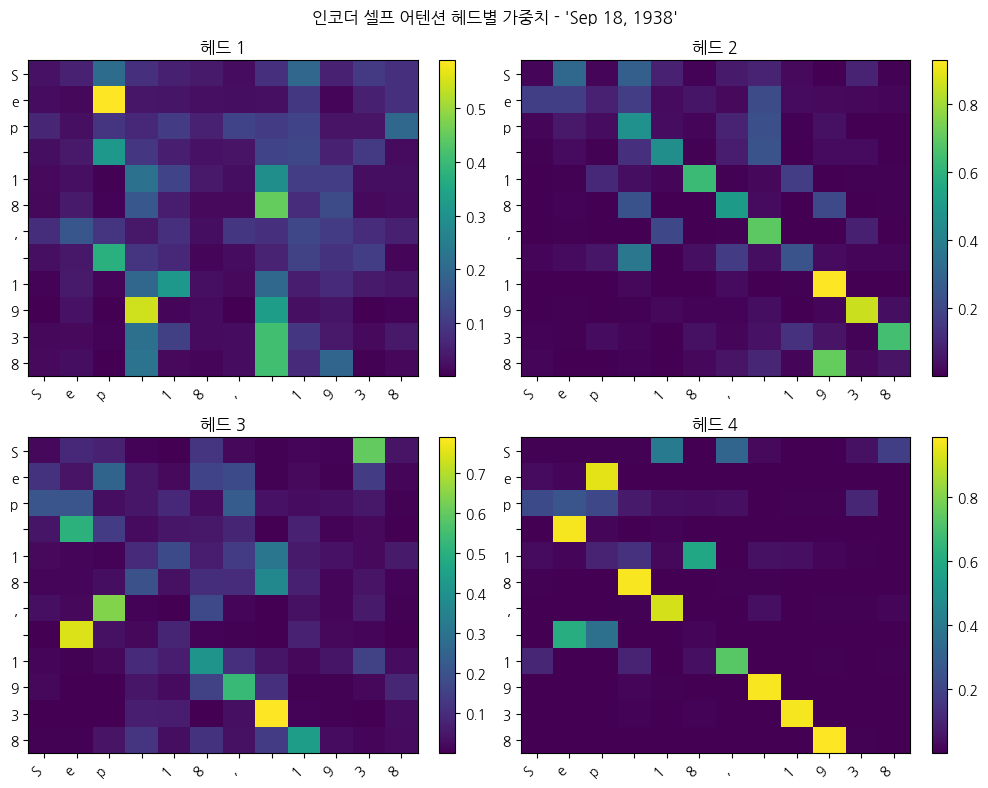

In [14]:
# 참고 - 헤드별 어텐션 가중치 히트맵 시각화
import numpy as np
import matplotlib.pyplot as plt

common.set_korean_plot_env()

num_heads = attn_4.shape[0]
src_tokens = list(demo_src)
seq_length = len(src_tokens)
attn_to_show = attn_4[:, :seq_length, :seq_length]  # PAD 영역 제외

cols = 2
rows = (num_heads + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
axes = np.atleast_1d(axes).flatten()
for h in range(num_heads):
    ax = axes[h]
    im = ax.imshow(attn_to_show[h], cmap='viridis', aspect='auto')
    ax.set_xticks(range(seq_length))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticks(range(seq_length))
    ax.set_yticklabels(src_tokens)
    ax.set_title(f'헤드 {h + 1}')
    plt.colorbar(im, ax=ax, fraction=0.046)
for h in range(num_heads, len(axes)):
    axes[h].axis('off')
fig.suptitle(f'인코더 셀프 어텐션 헤드별 가중치 - {demo_src!r}', fontsize=12)
plt.tight_layout()
plt.show()

- 각 헤드의 가중치 패턴이 서로 다르다는 사실을 확인할 수 있다. 여러 관점을 동시에 보는 것이 멀티헤드 어텐션의 효과다.

## 참고 - 학습률 워밍업([연습문제 10-3])

- 트랜스포머 모델은 학습 초기에 파라미터 초깃값과 학습률에 민감해 학습이 불안정해지기 쉽다.
    - 처음에는 낮은 학습률로 시작해 점차 높이는 학습률 워밍업 방식으로 이를 완화할 수 있다.
- 본문 [코드 10-7]은 학습 도중에 Adam 옵티마이저의 학습률을 바꾸는 방법을 보여 준다.

```python
for param_group in optimizer.param_groups:
    param_group['lr'] = NEW_LR
```

- 다음 학습 루프는 11 에포크부터 학습률을 `late_lr`로 바꾼다. 헤드 수 1과 4인 모델에 각각 적용해 비교한다.

In [15]:
# 참고 - 학습률 워밍업을 적용한 학습 루프([코드 10-7] 포함)
#   워밍업의 효과는 학습 초기에 드러나므로 데모는 에포크 상한을 낮춰 실행한다.
WARMUP_EPOCHS = 40

def train_loop_wu(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device, late_lr, verbose=True):
    """조기 종료 + 최적 모델 복원 학습 루프.

    학습 로그·전체 학습 시간·최적 에포크·학습 곡선은 공통코드컨벤션
    §7.6/§7.7에 따라 common.EpochLogger로 통일한다(검증 손실·정확도가
    있으므로 훈련 손실·검증 손실·정확도(%) 3열). verbose=False면 표·요약
    출력을 접어 두고 로그만 누적하며(어텐션 데모용), 곡선·최적 에포크
    정보는 반환 객체로 그대로 얻을 수 있다.
    """
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)        # 훈련 손실 · 검증 손실 · 정확도(%)
    best_valid_loss = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        if epoch == 11:
            for param_group in optimizer.param_groups:
                param_group['lr'] = late_lr
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        valid_loss, valid_acc = validation(
            model, valid_loader, criterion, device,
        )
        # valid_acc는 이미 백분율 수(0~100)
        if verbose:
            log.row(epoch, train_loss, valid_loss, valid_acc)
        else:
            # 표를 찍지 않고 이력만 누적 (헤더·행 출력 생략)
            with contextlib.redirect_stdout(io.StringIO()):
                log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    if verbose:
        log.summary(stopped='조기 종료' if stopped else None)
    return {
        'log': log,
        'best_epoch': best_epoch,
        'best_valid_loss': best_valid_loss,
        'stopped': stopped,
    }

EARLY_LR = 1e-4
LATE_LR = 1e-3

In [16]:
# 참고 - 1헤드 모델 워밍업 학습 (간단 데모용)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
model_wu = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    d_model=D_MODEL, num_heads=1, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)
optimizer_wu = optim.Adam(model_wu.parameters(), lr=EARLY_LR)
criterion_wu = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

history_wu = train_loop_wu(
    model_wu, train_loader, valid_loader, criterion_wu, optimizer_wu,
    epochs=WARMUP_EPOCHS, patience=PATIENCE, device=device, late_lr=LATE_LR, verbose=True,
)
log_wu = history_wu['log']
print(f'1헤드 모델 워밍업 학습 완료 - 최적 에포크 {history_wu["best_epoch"]}, '
      f'최적 검증 손실 {history_wu["best_valid_loss"]:.4f}')

에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/40       2.2761       1.8282        0.00%     0:01


  2/40       1.6716       1.4029        0.00%     0:02


  3/40       1.4080       1.2608        0.00%     0:03


  4/40       1.2981       1.1933        0.00%     0:05


  5/40       1.2380       1.1485        0.00%     0:06


...

 36/40       0.4310       0.2056       51.30%     0:42


 37/40       0.4265       0.1998       52.70%     0:43


 38/40       0.4194       0.1849       54.10%     0:45


 39/40       0.4019       0.1729       55.10%     0:46


 40/40       0.3924       0.1737       57.20%     0:47
------------------------------------------------------
최적 39 에포크 · 검증 손실 0.1729 · 전체 학습 시간 0:47
1헤드 모델 워밍업 학습 완료 - 최적 에포크 39, 최적 검증 손실 0.1729


In [17]:
# 참고 - 4헤드 모델 워밍업 학습 (간단 데모용)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model_wu = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    d_model=D_MODEL, num_heads=4, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)
optimizer_wu = optim.Adam(model_wu.parameters(), lr=EARLY_LR)
criterion_wu = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

history_wu = train_loop_wu(
    model_wu, train_loader, valid_loader, criterion_wu, optimizer_wu,
    epochs=WARMUP_EPOCHS, patience=PATIENCE, device=device, late_lr=LATE_LR, verbose=True,
)
log_wu = history_wu['log']
print(f'4헤드 모델 워밍업 학습 완료 - 최적 에포크 {history_wu["best_epoch"]}, '
      f'최적 검증 손실 {history_wu["best_valid_loss"]:.4f}')

에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/40       2.2750       1.8439        0.00%     0:01


  2/40       1.7036       1.4384        0.00%     0:03


  3/40       1.4279       1.2790        0.00%     0:04


  4/40       1.3051       1.2014        0.00%     0:05


  5/40       1.2320       1.1481        0.00%     0:06


...

 36/40       0.5894       0.6131        6.10%     0:45


 37/40       0.5727       0.6042        7.10%     0:46


 38/40       0.5636       0.5761        7.90%     0:48


 39/40       0.5485       0.5510       10.90%     0:49


 40/40       0.5310       0.5313       13.40%     0:50
------------------------------------------------------
최적 40 에포크 · 검증 손실 0.5313 · 전체 학습 시간 0:50
4헤드 모델 워밍업 학습 완료 - 최적 에포크 40, 최적 검증 손실 0.5313


## 정리

- 트랜스포머는 순환 구조 없이 어텐션만으로 순차 데이터를 처리하므로 학습을 병렬화할 수 있다.
- 순서 정보는 위치 인코딩으로 넣어 준다. 학습 가능한 위치 인코딩은 위치 인덱스를 임베딩으로 벡터화해 토큰 임베딩에 더한다.
- 디코더의 셀프 어텐션에는 인과 마스크를, 패딩이 있는 입력에는 패딩 마스크를 적용한다.
- 학습은 병렬로, 추론은 순서대로 동작하는 것이 트랜스포머 디코더의 특성이다.
- 멀티헤드 어텐션은 파라미터 수를 늘리지 않고도 표현력을 끌어올린다.